# Composizione del dataframe (data analysis)
In questo notebook vengono modellati i dati ottenuti dal dataset [Italian Serie A (football)](https://datahub.io/football/italian-serie-a), a partire dalla stagione 2020/2021 fino alla 2025/2026. A seguito indichiamo i campi che vengono mantenuti e quelli eliminati, elencandone le motivazioni.

## Installazione delle librerie
Per l'analisi dei dati, utilizziamo le seguenti librerie:
- Pandas
- Numpy
che sono installate nell'ambiente virtuale che stiamo utilizzando, e che vengono importate nel seguente blocco

In [50]:
import numpy as np
import pandas as pd

## Importazione dataset
Nella seguente cella vengono importati i dataset che utilizziamo per l'analisi dei dati. Essendo separati li uniamo tramite la funzione di pandas "concat", e successivamente
li andiamo ad analizzare 

In [51]:
import glob
import os

# Indico la cartella nella quale sono contenuti i dataset
path_cartella = 'static/dataset'

csv_files = os.path.join(path_cartella, "*.csv")
all_files = glob.glob(csv_files)

# Creo un array di dataframe e li concateno
lista_dataframe = [pd.read_csv(file) for file in all_files]
raw_dataset = pd.concat(lista_dataframe, axis=0, ignore_index=True)

# Converto la colonna 'Date' a un formato data
raw_dataset['Date'] = pd.to_datetime(raw_dataset['Date'])

# Ordino l'intero dataset usando la colonna 'Date'
raw_dataset = raw_dataset.sort_values(by='Date', ascending=False)

# Resetto gli indici
raw_dataset = raw_dataset.reset_index(drop=True)

raw_dataset.head()


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2026-05-24,Lecce,Genoa,1,0,H,1,0,H,NaN,...,4,1,11,6,1,6,2,0,0,0
1,2026-05-24,Cremonese,Como,1,4,A,0,1,A,NaN,...,1,6,14,12,2,4,4,2,3,0
2,2026-05-24,Parma,Sassuolo,1,0,H,0,0,D,NaN,...,3,1,10,14,1,1,2,2,0,0
3,2026-05-24,Napoli,Udinese,1,0,H,1,0,H,NaN,...,6,3,3,13,3,3,0,3,0,1
4,2026-05-24,Milan,Cagliari,1,2,A,1,1,D,NaN,...,3,10,8,9,5,5,2,2,0,0


## Rimozione dati aggiuntivi

Rimuoviamo i dati meno rilevati ai fini dell nostra analisi dal dataset. Focalizzandoci sui seguenti 
- Data partita
- Squadra locale ed ospite
- FTHG (Full Time Home Goals) FTAG (Full Time Away Goals)
- FTR (Full Time Result)
- HST (Home Shots on Target) AST (Away Shots on Target) 

In [52]:
new_index = [
    'Date',
    'HomeTeam',
    'AwayTeam',     
    'FTHG',
    'FTAG',
    'HST',
    'AST',
    'FTR'
]

clean_dataset = raw_dataset[new_index]
clean_dataset.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,HST,AST,FTR
0,2026-05-24,Lecce,Genoa,1,0,4,1,H
1,2026-05-24,Cremonese,Como,1,4,1,6,A
2,2026-05-24,Parma,Sassuolo,1,0,3,1,H
3,2026-05-24,Napoli,Udinese,1,0,6,3,H
4,2026-05-24,Milan,Cagliari,1,2,3,10,A


## Creazione di nuove colonne
Adesso tramire il dataframe rifinito e i suoi attributi, ne creiamo di nuovi, derviati, da utilizzare per l'allenamento del modello
che andremmo successivamente a generare. In particolare aggiungiamo 6 nuove categorie, ovvero:
- Stagione del campionato della riga di riferimento, in formato anno1-anno2 (es. 2023-2024);
- Media delle vittore delle ultime 5 partite;
- Differenza reti delle ultime 5 partite
- Media del rapporto $\frac{GOAL}{TIRI\_IN\_PORTA}$ delle ultime 5 partite;
- **Home advantage**, ovvero la percentuale delle vittorie in casa nelle ultime 5 partite.
- Punti cumulativi (quanti punti ha effettuato la squadra fino a quella partita esclusa)


### Stagione del campionato
Questo campo è facilmente derivabile dalla data in cui si disputa la partita: se è svolta prima di Luglio dell'anno X, allora la stagione sarà (X-1)-(X), caso contrario sarà (X)-X(X+1).

In [53]:
# Ottengo gli anni della stagione in base alla data
years = clean_dataset['Date'].dt.year
months = clean_dataset['Date'].dt.month

left_year = years.where(months > 7, years - 1)
right_year = left_year + 1

# Aggiungo la categoria "Season" al dataset
season_dataset = clean_dataset.copy()
season_dataset["Season"] = left_year.astype(str) + "-" + right_year.astype(str)

season_dataset.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,HST,AST,FTR,Season
0,2026-05-24,Lecce,Genoa,1,0,4,1,H,2025-2026
1,2026-05-24,Cremonese,Como,1,4,1,6,A,2025-2026
2,2026-05-24,Parma,Sassuolo,1,0,3,1,H,2025-2026
3,2026-05-24,Napoli,Udinese,1,0,6,3,H,2025-2026
4,2026-05-24,Milan,Cagliari,1,2,3,10,A,2025-2026


### Streak di vittorie
La strak di vittorie indica il numero di vittorie consecutive che ha ottenuto una squadra prima della partita interessata.

In [54]:
# Ordino il dataset per stagione e per data
streak_dataset = season_dataset.copy()
streak_dataset = streak_dataset.sort_values(by=['Season', 'Date']).reset_index(drop=True)

# Creazione delle nuove colonne 
streak_dataset['Home_WinStreak'] = 0
streak_dataset['Away_WinStreak'] = 0

for season in streak_dataset['Season'].unique():
    
    # Selezione della stagione d'interesse
    season_mask = streak_dataset['Season'] == season
    
    current_streak = {}
    
    for index, row in streak_dataset[season_mask].iterrows():
        
        home = row['HomeTeam']
        away = row['AwayTeam']
        
        
        if home not in current_streak: 
            current_streak[home] = 0
        if away not in current_streak: 
            current_streak[away] = 0
        
        # Assegnazione dello streak
        streak_dataset.at[index, 'Home_WinStreak'] = current_streak[home]
        streak_dataset.at[index, 'Away_WinStreak'] = current_streak[away]
        
        if row['FTR'] == 'H': 
            current_streak[home] += 1
            current_streak[away] = 0 
            
        elif row['FTR'] == 'A': 
            current_streak[away] += 1
            current_streak[home] = 0  
            
        else: 
            current_streak[home] = 0
            current_streak[away] = 0

# Riordino le partite dalla più alla meno recente
streak_dataset = streak_dataset.sort_values(by=['Season', 'Date'], ascending=False).reset_index(drop=True)


### Media vittorie e goal effettuati ultime 5 giornate

Per calcolare la media delle vittorie per squadra nelle ultime 5 partite, inizialmente creiamo colonne fittizie nel dataset per identificare le vittorie, e successivamente le raggruppiamo ad insiemi di 5 per ogni squadra.

In [55]:
# Creo le colonne temporanee booleane per identificare le vittorie
streak_dataset["Home_Win"] = np.where(streak_dataset["FTR"] == "H", 1, 0)
streak_dataset["Away_Win"] = np.where(streak_dataset["FTR"] == "A", 1, 0)

# Sdoppio il dataset dal punto di vista della singola squadra
as_home = streak_dataset[["Date","Season", "HomeTeam", "FTHG", "Home_Win"]].copy()
as_home.columns = ["Date","Season", "Team", "Goals", "Win"]
as_home["Home"] = 1

as_away = streak_dataset[["Date","Season", "AwayTeam", "FTAG", "Away_Win"]].copy()
as_away.columns = ["Date","Season", "Team", "Goals", "Win"]
as_away["Home"] = 0

# Unisco e ordino per squadra e data
team_date = pd.concat([as_home, as_away]).sort_values(["Season","Team", "Date"])


# Calcolo le medie di interesse. La funzione rolling serve a calcolare la media mobile
# basata su una finestra temporale di massimo 5 partite precedenti.
# Lo shift invece serve a non contare la partita in esame come facente parte delle 5 precedenti.
team_date["Avg_Goals_last_5"] = (
    team_date.groupby(["Team","Season"])["Goals"]
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

team_date["Avg_Wins_last_5"] = (
    team_date.groupby(["Team","Season"])["Win"]
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

# Gestisco i NaN inserendo 0 per le prime partite di campionato dove lo shift non trova dati passati
team_date["Avg_Goals_last_5"] = team_date["Avg_Goals_last_5"].fillna(0)
team_date["Avg_Wins_last_5"] = team_date["Avg_Wins_last_5"].fillna(0)

# Separo le medie calcolate per le partite in casa e per quelle in trasferta
avg_home = team_date[team_date["Home"] == 1][
    ["Date","Season", "Team", "Avg_Goals_last_5", "Avg_Wins_last_5"]
]
avg_home.columns = [
    "Date",
    "Season",
    "HomeTeam",
    "AvgH_Goals_Last5",
    "AvgH_Wins_Last5",
]

avg_away = team_date[team_date["Home"] == 0][
    ["Date","Season", "Team", "Avg_Goals_last_5", "Avg_Wins_last_5"]
]
avg_away.columns = [
    "Date",
    "Season",
    "AwayTeam",
    "AvgA_Goals_Last5",
    "AvgA_Wins_Last5",
]

avg_last5_dataset = streak_dataset.copy()

# Unisco i dati appena calcolati al dataset di riferimento
avg_last5_dataset = pd.merge(avg_last5_dataset, avg_home, on=["Date","Season", "HomeTeam"], how="left")
avg_last5_dataset = pd.merge(avg_last5_dataset, avg_away, on=["Date","Season", "AwayTeam"], how="left")

# Rimuovo le colonne fittizie d'utilità create inizialmente
avg_last5_dataset = avg_last5_dataset.drop(columns=["Home_Win", "Away_Win"])

### Rapporto goal/tiri in porta
In questa cella viene calcolato il rapporto goal/tiri in porta delle (massimo) ultime 5 partite, tenendo conto che le ultime 5 partite devono essere considerate nello stesso campionato della partita indicata, non in quello precedente. Verranno aggiunti due nuovi campi, ovvero
- GoalOnShotRatioHome;
- GoalOnShotRatioAway.

Per il calcolo di questi valori dobbiamo prendere i valori delle ultime 5 partite, considerando i goal effettuati (FTAG, FTHG) e i tiri in porta (HST, AST) e calcolare i ratio delle singole partite, per poi effettuare la media tra di esse. 

In [56]:
from pandas import DataFrame

def goal_on_shot_ratio(data_frame: DataFrame) -> DataFrame:
    """
    Calcola il "goal_on_shot_ratio" medio delle ultime 5 partite per squadra e stagione.
    :params data_frame data frame dei dati
    :return data_frame contenente il GoalShotRatio
    """
    # 1. Calcolo il ratio della SINGOLA partita
    data_frame['MatchRatio'] = np.where(
        data_frame['Tiri_Porta'] > 0,
        data_frame['Gol'] / data_frame['Tiri_Porta'],
        0  
    )

    # 2. Raggruppo e faccio la MEDIA mobile dei ratio delle ultime (massimo) 5 partite
    data_frame['GoalShotRatio'] = data_frame.groupby(['Team', 'Season'])['MatchRatio'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )
    
    # Sostituisco eventuali NaN iniziali con 0
    data_frame['GoalShotRatio'] = data_frame['GoalShotRatio'].fillna(0)

    return data_frame[['Date', 'Team', 'GoalShotRatio']]


def merge_dataframe(feature_dataframe: DataFrame, final_dataframe: DataFrame, team_name: str, ratio_name: str) -> DataFrame:
    """
    Funzione che modifica il final_dataframe, inserendo i dati del ratio indicati nel feature_dataframe
    :param feature_dataframe datagrame delle nuove caratteristiche
    :param final_dataframe dataframe in cui calcolare il risultato
    :param team_name team di riferimento (HomeTeam o AwayTeam)
    :param ratio_name indice del ratio calcolato
    :return ritorna il dataframe finale modificato
    """

    final_dataframe = pd.merge(
        final_dataframe,
        feature_dataframe,
        left_on=['Date', team_name],
        right_on=['Date', 'Team'],
        how='left'
    )
    
    # Rinominazione della colonna
    final_dataframe.rename(columns={'GoalShotRatio': ratio_name}, inplace=True)
    final_dataframe.drop('Team', axis=1, inplace=True)

    return final_dataframe


In [57]:
# Colonne di utilità
utils_columns_h = ['Date', 'Season', 'HomeTeam', 'FTHG', 'HST']
utils_columns_a = ['Date', 'Season', 'AwayTeam', 'FTAG', 'AST']

# Trasformazioni colonne -> dataframe
transformation_h = {'HomeTeam': 'Team', 'FTHG': 'Gol', 'HST': 'Tiri_Porta'}
transformation_a = {'AwayTeam': 'Team', 'FTAG': 'Gol', 'AST': 'Tiri_Porta'}

# Squadra di casa
home_df = season_dataset[utils_columns_h].copy()
home_df.rename(columns=transformation_h, inplace=True)

# Squadra 
away_df = season_dataset[utils_columns_a].copy()
away_df.rename(columns=transformation_a, inplace=True)

# Unione dei dati (ordinati per data)
history = pd.concat([home_df, away_df], ignore_index=True)
history = history.sort_values(by=['Team', 'Date']).reset_index(drop=True)

utils_dataframe = goal_on_shot_ratio(history)
goal_ratio_dataset = avg_last5_dataset.copy()

goal_ratio_dataset = merge_dataframe(utils_dataframe, goal_ratio_dataset, "HomeTeam", "GoalOnShotRatioHome")
goal_ratio_dataset = merge_dataframe(utils_dataframe, goal_ratio_dataset, "AwayTeam", "GoalOnShotRatioAway")



### Home Advantage
Per il calcolo dell'Home Advantage abbiamo la necessità di trovare la percentuale delle ultime 5 partite in casa vinte, solo per la squadra che gioca in casa (sarebbe poco utile per la squadra in trasferta).

In [58]:
# Riutilizzo la variabile 'team_date' già calcolata in  un blocco precedente, prendendo le sole partite
# che sono state disputate in casa
home_only = team_date[team_date["Home"] == 1].copy()

# Calcolo la media pre-partita delle 5 ultime vittore in casa sulle partite disputate in casa 
home_only["HomeAdvantagePre"] = (
    home_only.groupby(["Team", "Season"])["Win"]
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

# Filtro i soli dati che mi interessano
home_advantage = home_only[["Date", "Season", "Team", "HomeAdvantagePre"]].sort_values(["Team", "Date"])
home_advantage_dataset = goal_ratio_dataset.copy()

home_advantage_dataset = pd.merge(
    home_advantage_dataset,
    home_advantage.rename(
        columns={"Team": "HomeTeam", "HomeAdvantagePre": "HomeAdvantage"}
    ),
    on=["Date", "Season", "HomeTeam"],
    how="left"
)

# Gestione dei dati null
home_advantage_dataset["HomeAdvantage"] = home_advantage_dataset["HomeAdvantage"].fillna(0)


### Classifica cumulativa

Per calcolare la classifica cumulativa, dove per ogni record del dataframe abbiamo i punti effettuati da ciascuna squadra fino a quel momento, calcoliamo i punti totali e poi sempre con il solito metodo della funzione shift() utilizzato in precedenza, escludiamo la partita corrente.  


In [59]:
# Assegno i punti della singola partita in base al risultato
home_advantage_dataset["Home_Points_Match"] = np.select(
    [home_advantage_dataset["FTR"] == "H", home_advantage_dataset["FTR"] == "D"], 
    [3, 1], 
    default=0
)
home_advantage_dataset["Away_Points_Match"] = np.select(
    [home_advantage_dataset["FTR"] == "A", home_advantage_dataset["FTR"] == "D"], 
    [3, 1], 
    default=0
)

# Sdoppio il dataset per raccogliere i punti dal punto di vista della singola squadra
# ed ottenere i punti effettuati in casa e in trasferta 
pts_home =home_advantage_dataset[["Date", "Season", "HomeTeam", "Home_Points_Match"]].copy()
pts_home.columns = ["Date", "Season", "Team", "Points"]

pts_away = home_advantage_dataset[["Date", "Season", "AwayTeam", "Away_Points_Match"]].copy()
pts_away.columns = ["Date", "Season", "Team", "Points"]

# Unisco con concat per ottenere i punti totali
team_pts = pd.concat([pts_home, pts_away]).sort_values(["Season", "Team", "Date"])

# Calcolo i punti cumulativi usando cumsum() per sommare e groupby per stagione per azzerare la classifica ad ogni nuova stagione
team_pts["Cumulative_Points"] = team_pts.groupby(["Season", "Team"])["Points"].cumsum()

# Uso shift per non contare la partita corrente
team_pts["Points_Before_Match"] = team_pts.groupby(["Season", "Team"])["Cumulative_Points"].shift(1).fillna(0).astype(int)

# Preparo i due dataframe di supporto per il merge finale
pts_to_merge_home = team_pts[["Date", "Team", "Points_Before_Match"]].copy()
pts_to_merge_home.columns = ["Date", "HomeTeam", "Home_Current_Points"]

pts_to_merge_away = team_pts[["Date", "Team", "Points_Before_Match"]].copy()
pts_to_merge_away.columns = ["Date", "AwayTeam", "Away_Current_Points"]

# Aggiungo i punti in classifica al dataset definitivo
final_dataset = pd.merge(home_advantage_dataset, pts_to_merge_home, on=["Date", "HomeTeam"], how="left")
final_dataset = pd.merge(final_dataset, pts_to_merge_away, on=["Date", "AwayTeam"], how="left")

# Pulisco le colonne temporanee utili al calcolo
final_dataset = final_dataset.drop(columns=["Home_Points_Match", "Away_Points_Match"])

final_dataset.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,HST,AST,FTR,Season,Home_WinStreak,Away_WinStreak,AvgH_Goals_Last5,AvgH_Wins_Last5,AvgA_Goals_Last5,AvgA_Wins_Last5,GoalOnShotRatioHome,GoalOnShotRatioAway,HomeAdvantage,Home_Current_Points,Away_Current_Points
0,2026-05-24,Lecce,Genoa,1,0,4,1,H,2025-2026,1,0,1.2,0.4,0.6,0.2,0.250000,0.180000,0.2,35,41
1,2026-05-24,Cremonese,Como,1,4,1,6,A,2025-2026,2,2,1.0,0.4,1.0,0.6,0.190000,0.345238,0.2,34,68
2,2026-05-24,Parma,Sassuolo,1,0,3,1,H,2025-2026,0,0,0.8,0.4,1.4,0.4,0.373333,0.295238,0.2,42,49
3,2026-05-24,Napoli,Udinese,1,0,6,3,H,2025-2026,1,0,1.8,0.4,1.4,0.4,0.288889,0.202381,0.6,73,50
4,2026-05-24,Milan,Cagliari,1,2,3,10,A,2025-2026,1,1,1.0,0.4,1.0,0.4,0.177778,0.250000,0.4,70,40


## Data Visualization

Una volta aggiunte tutte le feature necessarie, procediamo con la parte di data visualization, nella quale mostriamo la struttura del dataset analizzando in particolare:
- La distribuzione dei risultati (FTR), che rappresenterà il target per la parte di classificazione in Machine Learning.
- Se e come la differenza dei punti tra le due squadre influenza il risultato finale
- La correlazione tra le feature numeriche, in casa e fuori casa.

Per questa parte del notebook abbiamo utilizzato le due librerie princiapli che offre Python per la creazione dei grafici, ovvero:
- Matplotlib
- Seaborn

che importiamo nella seguente cella

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

### Distribuzione dei risultati

Procediamo con il primo punto, analizzando la distribuzione dei risultati. Dal grafico si può chiaramente vedere una prevalenza di vittorie in casa (H, circa 900 partite), seguita dalle vittorie in trasferta (A, circa 730) e infine dai pareggi (D, circa 600).
Il dataset riflette quindi la realtà calcistica, dove il fattore campo si conferma un aspetto determinante.   

Text(0, 0.5, 'Numero di Partite')

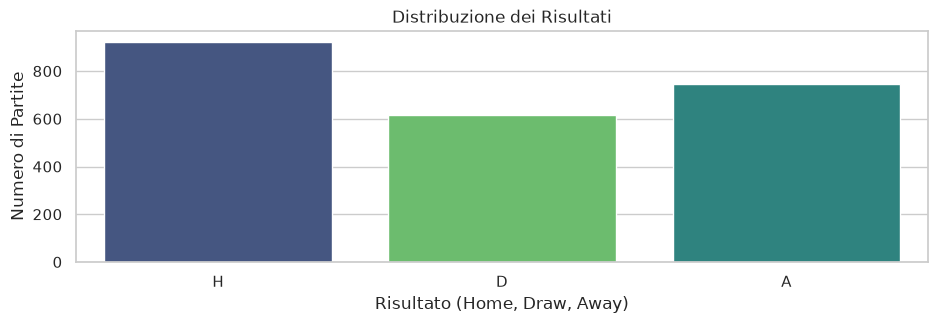

In [61]:
# Imposto la dimensione e lo stile del grafico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 3))


sns.countplot(data=final_dataset, x='FTR', order=['H', 'D', 'A'], hue='FTR', palette='viridis')
plt.title('Distribuzione dei Risultati')
plt.xlabel('Risultato (Home, Draw, Away)')
plt.ylabel('Numero di Partite')

### Distribuzione della differenza punti rispetto agli esiti finali

Analizziamo adesso il secondo punto. Dal grafico ottenuto possiamo confermare che la feature dei punti cumulativi che abbiamo calcolato è un indicatore fondamentale. Infatti, indica che se la squadra di casa ha più punti in classifica rispetto a quella ospite, la probabilità di vittoria interna sale notevolmente, e lo stesso viceversa.

Text(0, 0.5, 'Differenza punti (casa-ospite)')

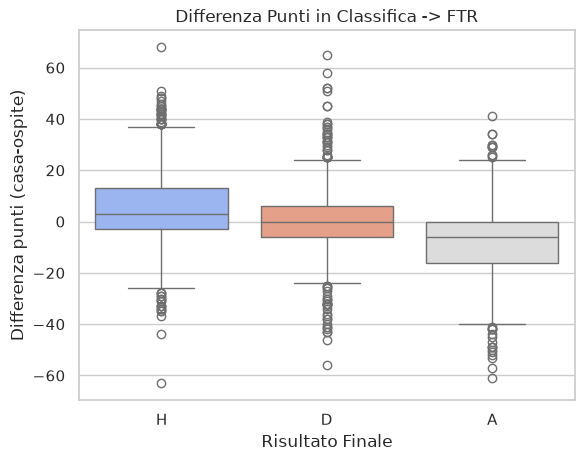

In [62]:
# Calcolo la differenza punti
final_dataset['Points_Difference'] = final_dataset['Home_Current_Points'] - final_dataset['Away_Current_Points']

sns.boxplot(data=final_dataset, x='FTR', y='Points_Difference', hue='FTR', order=['H', 'D', 'A'], palette='coolwarm')
plt.title('Differenza Punti in Classifica -> FTR')
plt.xlabel('Risultato Finale')
plt.ylabel('Differenza punti (casa-ospite)')


### Correlazione delle feature numeriche per "fattore campo"
Dai seguenti grafici possiamo individuare una serie di indici importanti, di cui andiamo a spiegarne uno. Una correlazione interessante è quella di Home_Current_Points e AvgH_Wins_Last5 (0.42), moderatamente elevata: è infatti logico pensare che una squadra con tanti punti abbia un coefficiente AvgH_Wins_Last5 elevato. Specifichiamo poi che i coefficienti di correlazione moderati riscontrati (compresi tra 0.20 e 0.50) riflettono la natura intrinsecamente imprevedibile e l'elevata varianza degli eventi sportivi.

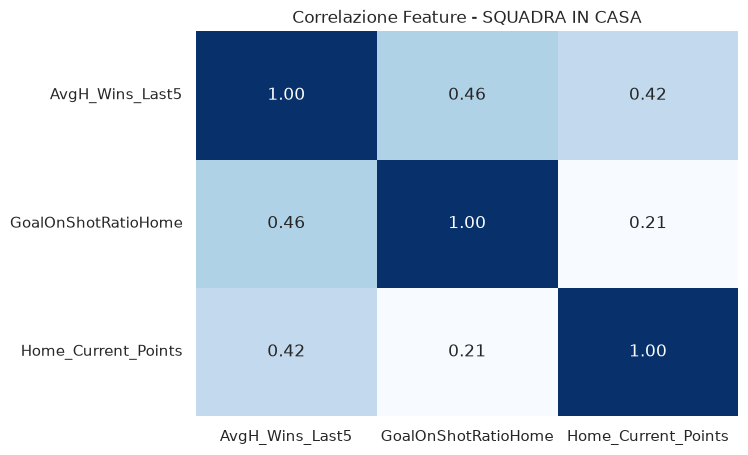

In [63]:
# Heatmap per la squadra in casa
plt.figure(figsize=(7, 5))
feature_home = ['AvgH_Wins_Last5', 'GoalOnShotRatioHome', 'Home_Current_Points']
sns.heatmap(final_dataset[feature_home].corr(), annot=True, cmap='Blues', fmt=".2f", cbar=False)

plt.title('Correlazione Feature - SQUADRA IN CASA')
plt.show()

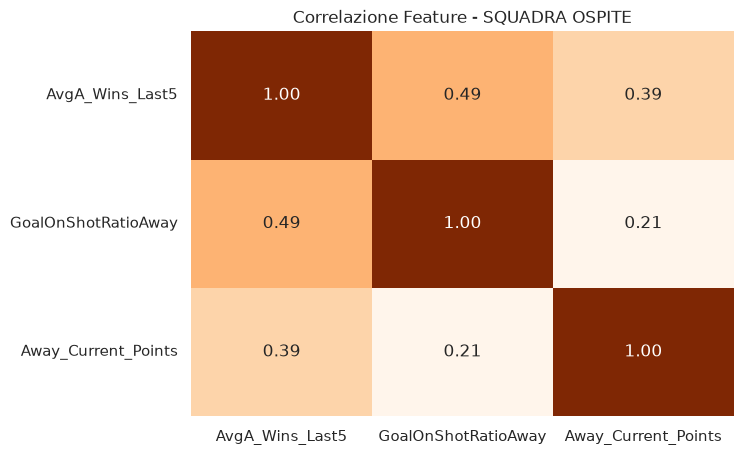

In [64]:
# Heatmap per la squadra in trasferta
plt.figure(figsize=(7, 5))
feature_away = ['AvgA_Wins_Last5', 'GoalOnShotRatioAway', 'Away_Current_Points']

sns.heatmap(final_dataset[feature_away].corr(), annot=True, cmap='Oranges', fmt=".2f", cbar=False)

plt.title('Correlazione Feature - SQUADRA OSPITE')
plt.show()

## Esportazione del dataset
Adesso è necessario esportare il dataset da noi creato, per effettuare le operazioni di **Machine Learning**. Il risultato verrà esportato nella cartella static/da-result, in formato CSV.

In [65]:
final_dataset.to_csv("static/da-result/result.csv", encoding='utf-8', index=False, header=True)